In [10]:
# load packages
import pandas as pd
import sys
import os
from itertools import product

In [11]:
# set path
PATH = '../data/fpts historical/'

In [12]:
# List all files in the PATH directory
files = os.listdir(PATH)

In [35]:
# define col names
col_names = [
    'OVERALL RK',
    'PLAYER NAME',
    'TEAM',
    'POS',
    'AGE',
    'G',
    'GS',
    'PASS CMP',
    'PASS ATT',
    'PASS YDS',
    'PASS TD',
    'PASS INT',
    'RUSH ATT',
    'RUSH YDS',
    'RUSH Y/A',
    'RUSH TD',
    'REC TGT',
    'REC REC',
    'REC YDS',
    'REC Y/R',
    'REC TD',
    'FMB',
    'FL',
    'TOT TD',
    '2PM',
    '2PP',
    'FANTPT',
    'PPR',
    'DKPT',
    'FDPT',
    'VBD',
    'POS RANK',
    'RK',
    'ID'
]

In [36]:
# define season values
seasons = [
    '2024', 
    '2023', 
    '2022', 
    '2021', 
    '2020', 
    '2019', 
    '2018', 
    '2017', 
    '2016', 
    '2015', 
    '2014'
]

In [37]:
for file in files:
    if file.startswith('s2'):
        print(file)

s2019.xlsx
s2023.xlsx
s2015.xlsx
s2014.xlsx
s2022.xlsx
s2018.xlsx
s2024.xlsx
s2021.xlsx
s2017.xlsx
s2016.xlsx
s2020.xlsx


In [38]:
## Data Processing

#initialize dict
data_dict = {}

# process files
for file in files:
    if file.startswith('s2'):
        # read data
        df = pd.read_excel(PATH + str(file))

        # drop row 0 (clean up)
        df = df.drop(0).reset_index(drop=True)

        # set col names
        df.columns = col_names

        # extract year from file name
        year = None
        for s in seasons:
            if s in file:
                year = s
                df['SEASON'] = year

        # save to dict
        data_dict[year] = df

In [39]:
data_dict['2024']

,OVERALL RK,PLAYER NAME,TEAM,POS,AGE,G,GS,PASS CMP,PASS ATT,PASS YDS,...,2PP,FANTPT,PPR,DKPT,FDPT,VBD,POS RANK,RK,ID,SEASON
0,1,Saquon Barkley*+,PHI,RB,27,16,16,0,0,0,...,NaN,322,355.3,362.3,338.8,163,1,1,BarkSa00,2024
1,2,Derrick Henry*,BAL,RB,30,17,17,0,0,0,...,NaN,317,336.4,343.4,326.9,159,2,2,HenrDe00,2024
2,3,Jahmyr Gibbs*,DET,RB,22,17,4,0,0,0,...,NaN,311,362.9,369.9,336.9,153,3,3,GibbJa01,2024
3,4,Lamar Jackson*+,BAL,QB,27,17,17,316,474,4172,...,NaN,430,430.4,445.4,434.4,140,1,4,JackLa00,2024
4,5,Ja'Marr Chase*+,CIN,WR,24,17,16,0,0,0,...,NaN,276,403,406,339.5,138,1,5,ChasJa00,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,626,Dylan Laube,LVR,RB,25,10,0,0,0,0,...,NaN,-2,-2,-1,-2,NaN,156,NaN,LaubDy00,2024
626,627,Steven Sims,2TM,WR,27,9,0,0,0,0,...,NaN,-2,-2,-1,-2,NaN,248,NaN,SimsSt00,2024
627,628,Kadarius Toney,CLE,WR,25,3,0,0,0,0,...,NaN,-2,-2.4,-1.4,-2.4,NaN,249,NaN,ToneKa00,2024
628,629,Clayton Tune,ARI,QB,25,6,0,2,2,8,...,NaN,-2,-2.1,-1.1,-2.1,NaN,79,NaN,TuneCl00,2024


In [40]:
# Clean Player Name column for each dataframe in data_dict
for year, df in data_dict.items():
    # Remove special characters from PLAYER NAME column
    df['PLAYER NAME'] = df['PLAYER NAME'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
    # Update the dataframe in the dictionary
    data_dict[year] = df

# Combine all dataframes
combined_df = pd.concat(data_dict.values(), ignore_index=True)

# Display first few rows to verify cleaning
print("Sample of cleaned data:")
print(combined_df[['PLAYER NAME', 'SEASON']].head(10))


Sample of cleaned data:
           PLAYER NAME SEASON
0  Christian McCaffrey   2019
1        Lamar Jackson   2019
2        Derrick Henry   2019
3          Aaron Jones   2019
4      Ezekiel Elliott   2019
5          Dalvin Cook   2019
6       Michael Thomas   2019
7         Travis Kelce   2019
8           Nick Chubb   2019
9          Mark Ingram   2019


In [41]:
combined_df

,OVERALL RK,PLAYER NAME,TEAM,POS,AGE,G,GS,PASS CMP,PASS ATT,PASS YDS,...,2PP,FANTPT,PPR,DKPT,FDPT,VBD,POS RANK,RK,ID,SEASON
0,1,Christian McCaffrey,CAR,RB,23,16,16,0,2,0,...,NaN,355,471.2,477.2,413.2,215,1,1,McCaCh01,2019
1,2,Lamar Jackson,BAL,QB,22,15,15,265,401,3127,...,NaN,416,415.7,429.7,421.7,152,1,2,JackLa00,2019
2,3,Derrick Henry,TEN,RB,25,15,15,0,0,0,...,NaN,277,294.6,303.6,285.6,136,2,3,HenrDe00,2019
3,4,Aaron Jones,GNB,RB,25,16,16,0,0,0,...,NaN,266,314.8,322.8,290.3,125,3,4,JoneAa00,2019
4,5,Ezekiel Elliott,DAL,RB,24,16,16,0,0,0,...,NaN,258,311.7,319.7,284.7,117,4,5,ElliEz00,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6876,653,Dwayne Harris,CHI,WR,33,3,0,0,0,0,...,NaN,-2,-2,-1,-2,NaN,257,NaN,HarrDw00,2020
6877,654,Nate Sudfeld,PHI,QB,27,1,0,5,12,32,...,NaN,-2,-1.5,0.5,-0.5,NaN,82,NaN,SudfNa00,2020
6878,655,Nsimba Webster,LAR,WR,24,16,0,0,0,0,...,NaN,-2,-2,-1,-2,NaN,258,NaN,WebsNs00,2020
6879,656,Dede Westbrook,JAX,WR,27,2,0,0,0,0,...,NaN,-2,-0.6,0.4,-1.1,NaN,256,NaN,WestDe00,2020


In [42]:
# write file to csv
combined_df.to_csv(PATH + 'combined_data.csv', index=False)

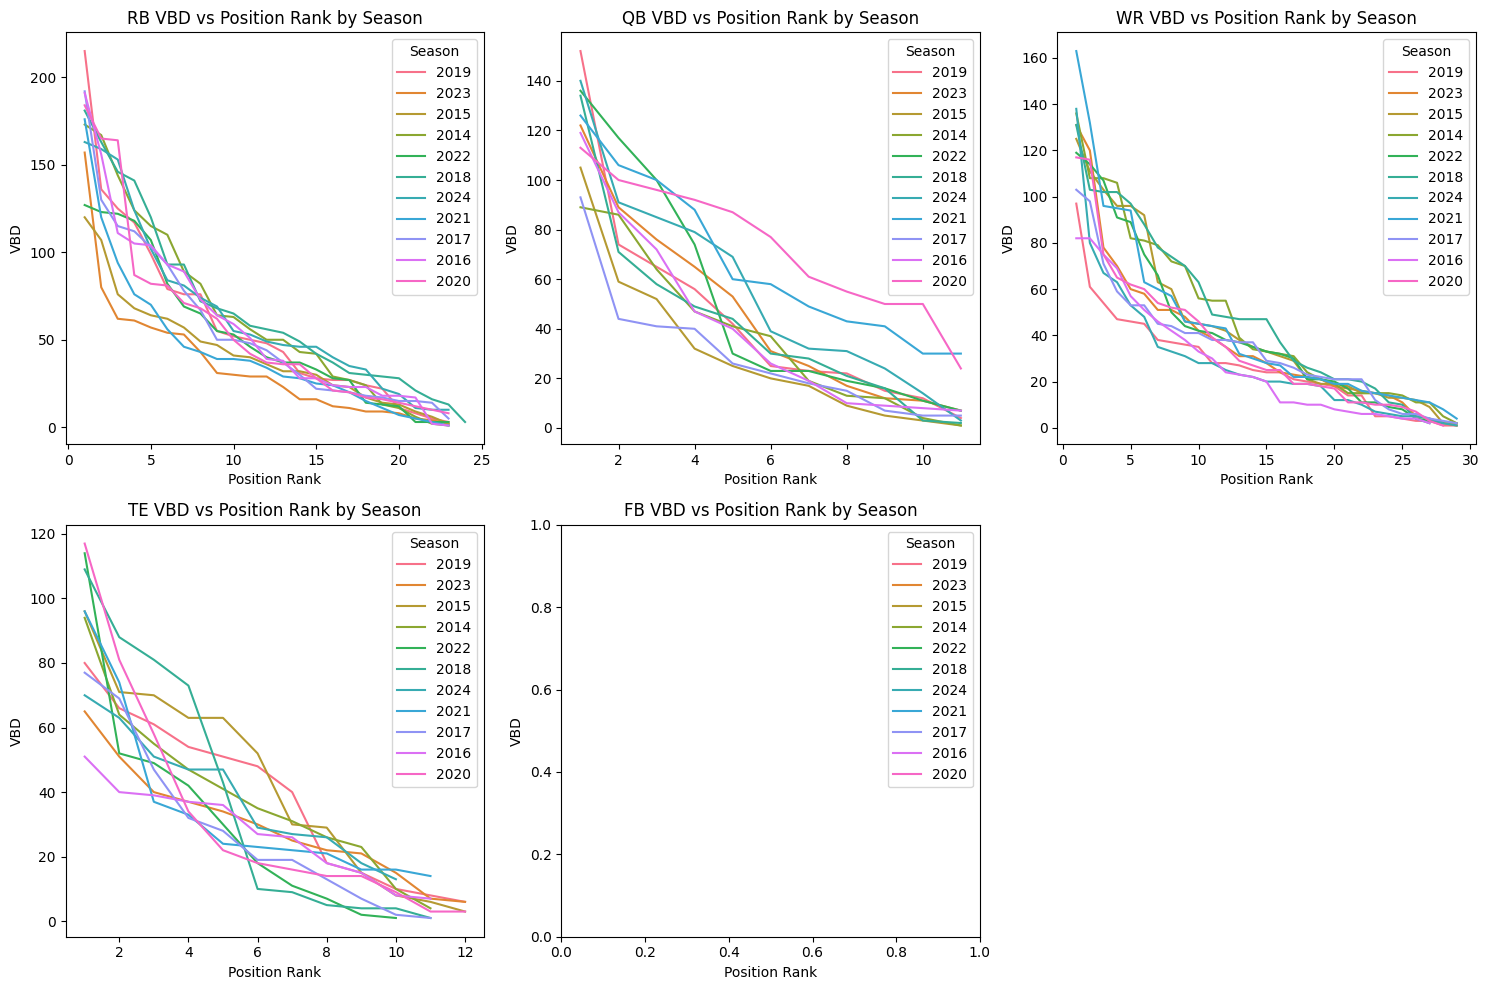

In [44]:
# Create a line plot of VBD vs PosRank by Season, split by FantPos
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique positions
positions = combined_df['POS'].unique()

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot for each position
for i, pos in enumerate(positions):
    if i < len(axes):  # Ensure we don't exceed the number of subplots
        pos_data = combined_df[combined_df['POS'] == pos]
        
        # Create line plot
        sns.lineplot(data=pos_data, x='POS RANK', y='VBD', hue='SEASON', ax=axes[i])
        axes[i].set_title(f'{pos} VBD vs Position Rank by Season')
        axes[i].set_xlabel('Position Rank')
        axes[i].set_ylabel('VBD')
        axes[i].legend(title='Season')

# Hide empty subplots if any
for i in range(len(positions), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

